Całość ma na celu stworzenie algorytmu klasyfikacji drzew od podstaw (czyli bez żadnych gotowych rozwiązań, ale numpy, pandas itp. dozwolone) oraz porównanie wyników z innymi metodami, takimi jak: KNN, Regresja logistyczna i Random Forest.

Poniższa sekcja zawiera klase i funkcje używane później do stworzenia drzewa i predykcji za jego pomocą, tak samo jak index Giniego.

In [1]:
import pandas as pd



class Node:
    def __init__(self, feature=None, children=None, label=None):
        self.feature = feature # cecha do podziału
        self.children = children or {}  # dict: wartość -> Node
        self.label = label # jeśli liść


def gini_index(dane_frame, cecha : str):
    n = dane_frame.shape[0]
    grouped = dane_frame.groupby(cecha)
    
    gini_value = 0

    for x, dataframe in grouped:
        rows = dataframe.shape[0]

        sum_edible = (dataframe['class'] == 'e').sum()
        sum_poisonous = (dataframe['class'] == 'p').sum()

        g = 1 - pow(sum_edible/rows, 2) - pow(sum_poisonous/rows, 2)
        w = rows/n
        gini_value += w*g
    
    return gini_value, cecha


def best_feature(df, features):
    best = None
    best_gini = float('inf') # Pozytywna nieskończoność, bo index giniego ma być jak najmniejszy

    for feature in features:
        g = gini_index(df, feature)[0]
        if g < best_gini:
            best_gini = g
            best = feature

    return best


def predict(node, sample):
    if node.label is not None:
        return node.label

    value = sample[node.feature]

    if value in node.children:
        return predict(node.children[value], sample)
    else:
        return None
    

def build_tree(df, features, depth=0, max_depth=10):
    # jeśli wszystkie klasy takie same, to liść
    if len(df['class'].unique()) == 1:
        return Node(label=df['class'].iloc[0])

    # warunek stopu
    if depth >= max_depth or len(features) == 0:
        return Node(label=df['class'].mode()[0])

    # wybór najlepszej cechy
    best = best_feature(df, features)
    node = Node(feature=best)

    for value, subset in df.groupby(best):
        if subset.empty:
            node.children[value] = Node(label=df['class'].mode()[0])
        else:
            node.children[value] = build_tree(
                subset,
                [f for f in features if f != best],
                depth + 1,
                max_depth
            )

    return node


Poniżej jest kod budowania drzewa, i oceny jego predykcji

In [2]:
import pandas as pd


df = pd.read_csv("mushrooms.csv")
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['class'].value_counts()}\n")
 

# Podział na test i train
df = df.sample(frac=1, random_state=42).reset_index(drop=True) 
split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx].reset_index(drop=True)
test_df   = df.iloc[split_idx:].reset_index(drop=True)
print(f"Training samples : {len(train_df)}")
print(f"Testing  samples : {len(test_df)}\n")
 
 
# Budowanie drzewa
features = [col for col in df.columns if col != "class"]
tree = build_tree(train_df, features, depth=0, max_depth=10)
 

def evaluate_custom_tree(tree, test_df):
    correct = 0
    total   = len(test_df)
    unknown = 0
 
    for _, row in test_df.iterrows():
        prediction = predict(tree, row)
 
        if prediction is None:
            unknown += 1
            continue
 
        if prediction == row["class"]:
            correct += 1
 
    accuracy = correct / (total - unknown) if (total - unknown) > 0 else 0
    return accuracy, correct, total, unknown

 
accuracy, correct, total, unknown = evaluate_custom_tree(tree, test_df)
 
print("── Wyniki ──────────────")
print(f"Correct predictions: {correct} / {total - unknown}")
print(f"Unpredictable rows: {unknown} (Takie z brakującymi danymi)")
print(f"Accuracy: {accuracy * 100:.2f}%\n")
 
 
# Pokaz paru wartości
print("── Predykcja dla 5 pierwszych wierszy─────────")
print(f"{'#':<4} {'Aktualne':<10} {'Predykcja':<10} {'Poprawność'}")
print("-" * 36)
 
for i, (_, row) in enumerate(test_df.head(5).iterrows()):
    actual = row["class"]
    predicted = predict(tree, row)
    mark = "ok" if predicted == actual else "false"
    print(f"{i+1:<4} {'edible' if actual == 'e' else 'poisonous':<10} "
          f"{'edible' if predicted == 'e' else 'poisonous':<10} {mark}")


Dataset shape: (8124, 23)
Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Training samples : 6499
Testing  samples : 1625

── Wyniki ──────────────
Correct predictions: 1625 / 1625
Unpredictable rows: 0 (Takie z brakującymi danymi)
Accuracy: 100.00%

── Predykcja dla 5 pierwszych wierszy─────────
#    Aktualne   Predykcja  Poprawność
------------------------------------
1    edible     edible     ok
2    poisonous  poisonous  ok
3    poisonous  poisonous  ok
4    poisonous  poisonous  ok
5    poisonous  poisonous  ok


Poniżej jest porówananie i implementacja 3 kolejnych metod: KNN, Regresji i drzew losowych

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
 

df = pd.read_csv("mushrooms.csv")
print(f"Dataset shape : {df.shape}")
print(f"Class distribution:\n{df['class'].value_counts()}\n")


encoders = {}
df_encoded = df.copy()
for col in df.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le


X = df_encoded.drop(columns=["class"])
y = df_encoded["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
 
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}\n")
 
results = {}
 
 
# Statystyki
def evaluate_sklearn_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test, y_pred,
        target_names=encoders["class"].classes_,
        zero_division=0
    )
    print(f"── {name} {'─' * (55 - len(name))}")
    print(f"Accuracy : {accuracy * 100:.2f}%")
    print(report)
    return accuracy
 
 
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
results["Random Forest"] = evaluate_sklearn_model("Random Forest", rf, X_test, y_test)
 
 
# 2. Logistic Regression
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
 
lr = LogisticRegression(max_iter=100, random_state=42, solver="lbfgs")
lr.fit(X_train_s, y_train)
results["Logistic Regression"] = evaluate_sklearn_model("Logistic Regression", lr, X_test_s, y_test)
 
 
# 3. KNN
knn = KNeighborsClassifier(n_neighbors=2, metric="euclidean")
knn.fit(X_train, y_train)
results["KNN"] = evaluate_sklearn_model("KNN", knn, X_test, y_test)
 
 
# ── 5. Summary ────────────────────────────────────────────────────────────────
print("=" * 58)
print(f"{'PODSUMOWANIE DLA ACCURACY':^58}")
print("=" * 58)
print(f"  {'Algorytm':<35} {'Accuracy':>10}")
print("-" * 58)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<35} {acc*100:>9.2f}%")
print("=" * 58)

Dataset shape : (8124, 23)
Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Training samples : 6499
Testing  samples : 1625

── Random Forest ──────────────────────────────────────────
Accuracy : 100.00%
              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

── Logistic Regression ────────────────────────────────────
Accuracy : 96.25%
              precision    recall  f1-score   support

           e       0.96      0.96      0.96       842
           p       0.96      0.96      0.96       783

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625

── KNN ─────────────────────────────────

Poniżej wizualizacja drzewa powstałego wcześniej

Tree saved to decision_tree.png


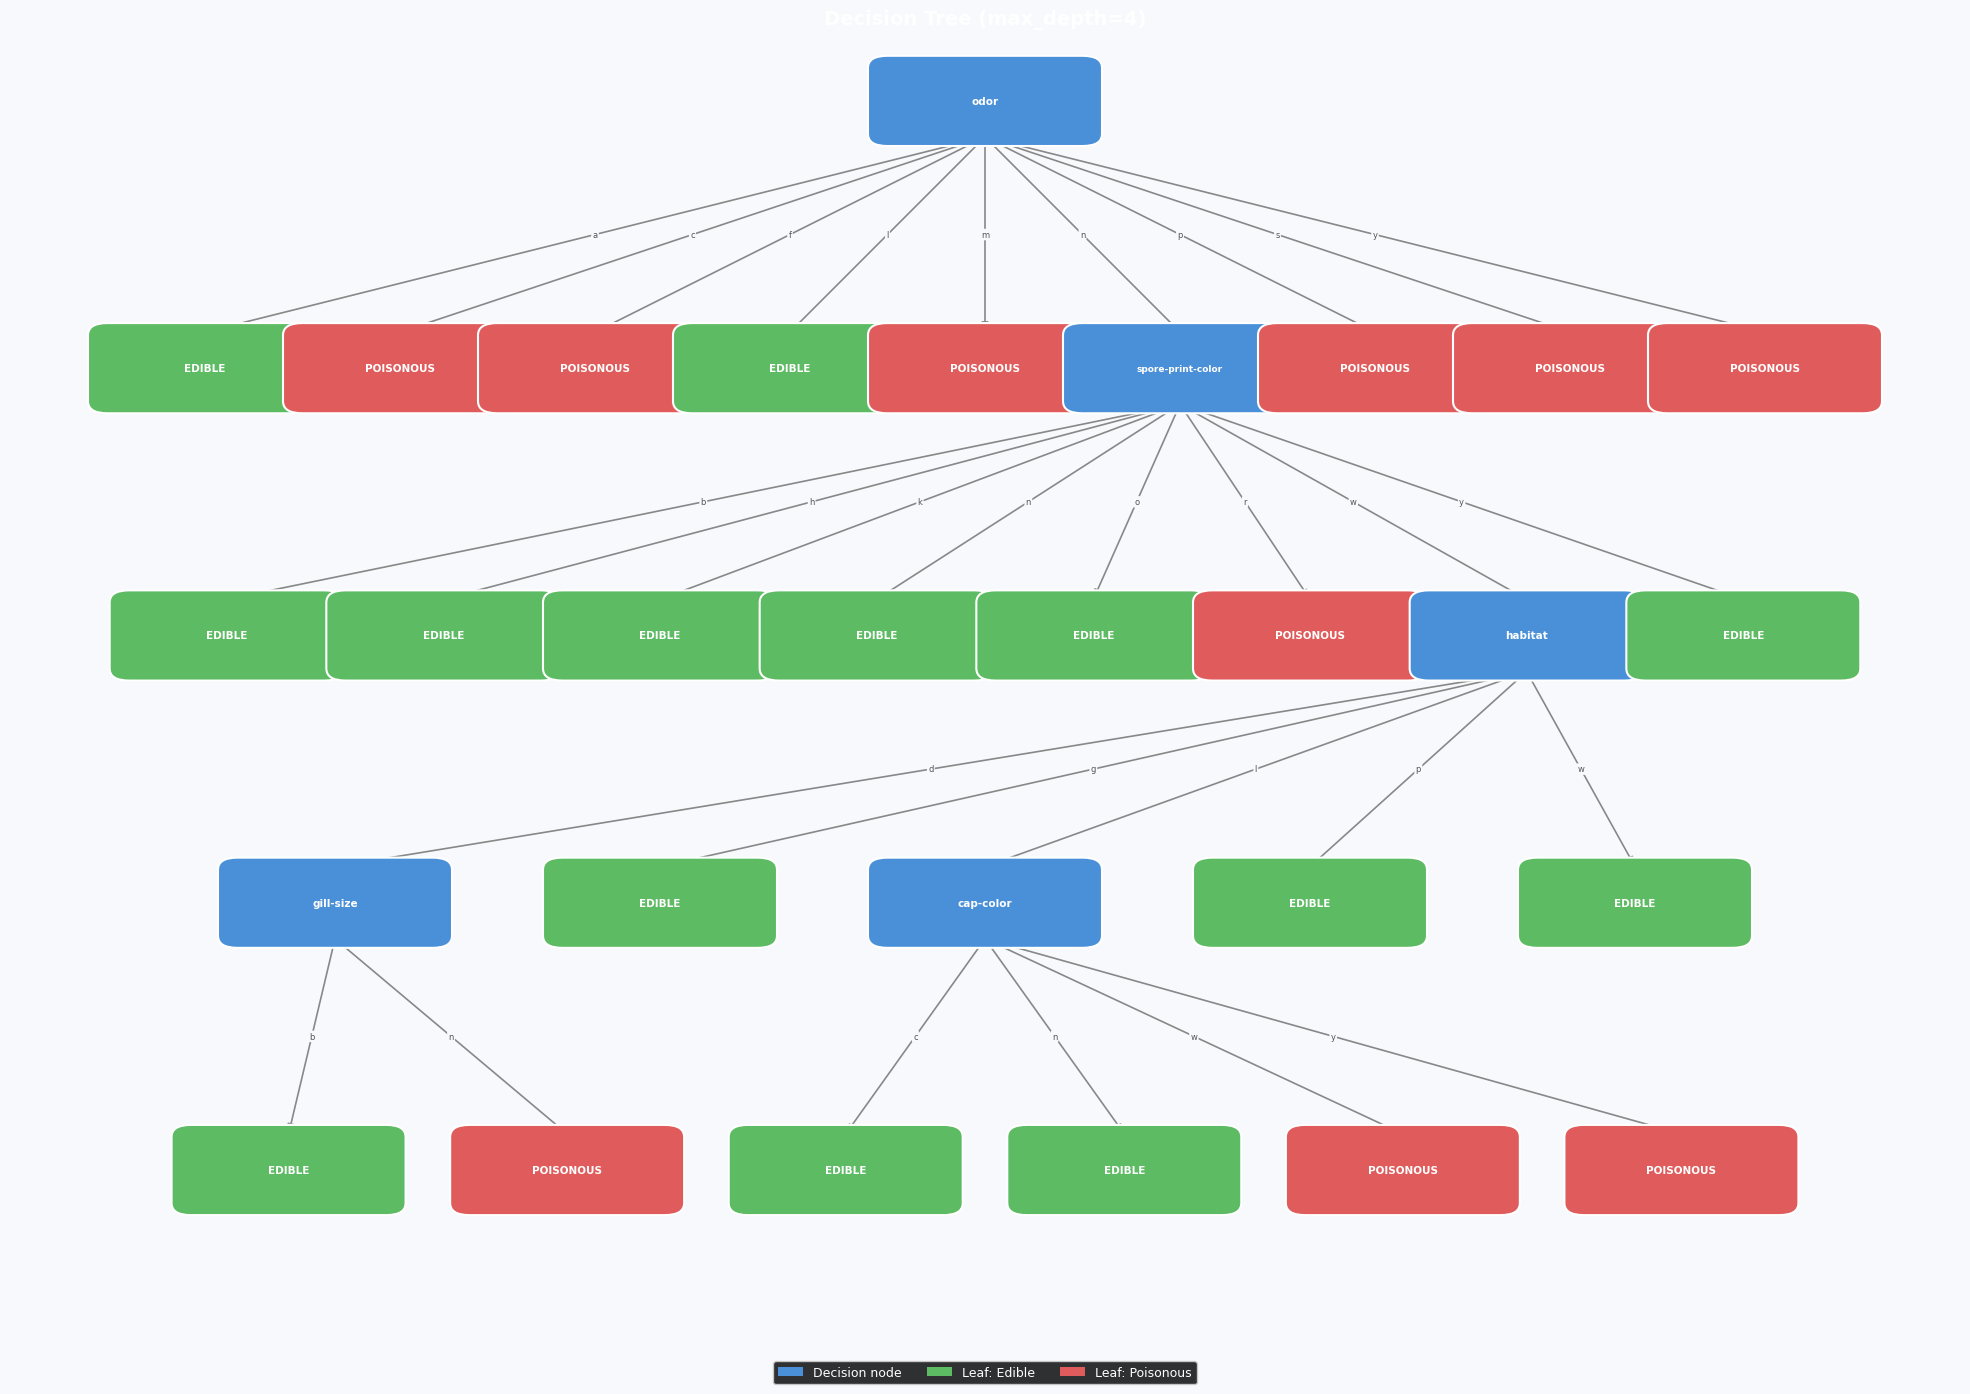

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Config ────────────────────────────────────────────────────────────────────
MAX_DEPTH     = 4      # keep the drawing readable (full tree is huge)
OUTPUT_FILE   = "decision_tree.png"
DPI           = 180
 
COLORS = {
    "node": "#4A90D9",
    "leaf_e":"#5DBB63",   # edible   → green
    "leaf_p":"#E05C5C",   # poisonous → red
    "edge":"#888888",
    "node_text": "white",
    "leaf_text": "white",
    "bg":"#F7F9FC",
}

def collect_nodes(node, depth=0, parent_id=None, edge_label="", nodes=None, edges=None):
    if nodes is None:
        nodes = []
        edges = []
    node_id = len(nodes)
    nodes.append({"id": node_id, "depth": depth, "node": node, "edge_label": edge_label})
    if parent_id is not None:
        edges.append((parent_id, node_id, edge_label))
    if node.label is None:
        for val, child in node.children.items():
            collect_nodes(child, depth + 1, node_id, str(val), nodes, edges)
    return nodes, edges
 
nodes, edges = collect_nodes(tree)
 
# Count nodes per depth to space them horizontally
from collections import defaultdict
depth_counts  = defaultdict(int)
depth_indices = defaultdict(int)
for n in nodes:
    depth_counts[n["depth"]] += 1
 
max_width = max(depth_counts.values())
 
# Assign x positions: spread evenly within [0, 1]
positions = {}
for n in nodes:
    d   = n["depth"]
    idx = depth_indices[d]
    cnt = depth_counts[d]
    x   = (idx + 1) / (cnt + 1)       # evenly spaced in [0,1]
    y   = 1.0 - d / (MAX_DEPTH + 0.5) # top = depth 0
    positions[n["id"]] = (x, y)
    depth_indices[d] += 1
 
 
# ── 3. Draw ───────────────────────────────────────────────────────────────────
fig_w = max(14, max_width * 2.2)
fig_h = (MAX_DEPTH + 1) * 2.8
 
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
 
# Build a quick id→node dict
id_to_node = {n["id"]: n for n in nodes}
 
# Draw edges first (so they sit behind boxes)
for parent_id, child_id, label in edges:
    px, py = positions[parent_id]
    cx, cy = positions[child_id]
    ax.annotate(
        "", xy=(cx, cy + 0.03), xytext=(px, py - 0.03),
        arrowprops=dict(arrowstyle="-|>", color=COLORS["edge"], lw=1.2)
    )
    mx, my = (px + cx) / 2, (py + cy) / 2
    ax.text(mx, my, label, fontsize=6, ha="center", va="center",
            color="#555555",
            bbox=dict(boxstyle="round,pad=0.15", fc=COLORS["bg"], ec="none"))
 
# Draw nodes
BOX_W = 0.10
BOX_H = 0.055
 
for n in nodes:
    nid  = n["id"]
    node = n["node"]
    x, y = positions[nid]
 
    if node.label is not None:
        # Leaf
        color = COLORS["leaf_e"] if node.label == "e" else COLORS["leaf_p"]
        label_str = "EDIBLE" if node.label == "e" else "POISONOUS"
    else:
        color     = COLORS["node"]
        label_str = node.feature
 
    fancy = mpatches.FancyBboxPatch(
        (x - BOX_W / 2, y - BOX_H / 2), BOX_W, BOX_H,
        boxstyle="round,pad=0.01",
        linewidth=1.5,
        edgecolor="white",
        facecolor=color,
        zorder=3,
        transform=ax.transData
    )
    ax.add_patch(fancy)
 
    fontsize = 6.5 if len(label_str) > 14 else 7.5
    ax.text(x, y, label_str, ha="center", va="center",
            fontsize=fontsize, fontweight="bold",
            color=COLORS["node_text"], zorder=4, wrap=True)
 
# Legend
legend_elements = [
    mpatches.Patch(facecolor=COLORS["node"],   label="Decision node"),
    mpatches.Patch(facecolor=COLORS["leaf_e"], label="Leaf: Edible"),
    mpatches.Patch(facecolor=COLORS["leaf_p"], label="Leaf: Poisonous"),
]
ax.legend(handles=legend_elements, loc="lower center",
          ncol=3, fontsize=9, framealpha=0.9,
          bbox_to_anchor=(0.5, -0.02))
 
plt.title(f"Decision Tree (max_depth={MAX_DEPTH})", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_FILE, dpi=DPI, bbox_inches="tight")
print(f"Tree saved to {OUTPUT_FILE}")
plt.show()

## Ewaluacja rozwiązania

W poniższych sekcjach znajdują się:
- **Macierze pomyłek** dla każdego algorytmu (confusion matrix)
- **Miary jakości**: Accuracy, Precision, Recall, F1-score
- **Krzywe ROC + AUC** dla wszystkich metod
- **Krzywa uczenia** (learning curve) dla Regresji Logistycznej i Random Forest
- **Porównanie wszystkich algorytmów** na wspólnym wykresie słupkowym

### Przygotowanie danych i modeli (wspólny setup dla wykresów)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

# --- encode ---
df_raw = pd.read_csv("mushrooms.csv")
encoders = {}
df_enc = df_raw.copy()
for col in df_raw.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_raw[col])
    encoders[col] = le

X = df_enc.drop(columns=["class"])
y = df_enc["class"]   # 0=edible, 1=poisonous after encoding

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- train models ---
rf  = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

lr = LogisticRegression(max_iter=100, random_state=42, solver="lbfgs")
lr.fit(X_train_s, y_train)

knn = KNeighborsClassifier(n_neighbors=2, metric="euclidean")
knn.fit(X_train, y_train)

# --- custom decision tree (zbudowane wcześniej w notebooku) ---
dt_acc, _, _, _ = evaluate_custom_tree(tree, test_df)   # używamy evaluate i tree z poprzednich komórek

MODELS = {
    "Decision Tree\n(własna impl.)": ("dt",  None, None),
    "Random Forest":                  ("rf",  rf,   X_test),
    "Logistic Regression":            ("lr",  lr,   X_test_s),
    "k-NN (k=2)":                     ("knn", knn,  X_test),
}

class_names = encoders["class"].classes_   # ['e', 'p']
print("Setup gotowy. Klasy:", class_names)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Setup gotowy. Klasy: ['e' 'p']
Train: 6499  Test: 1625


### Macierze pomyłek (Confusion Matrices)

Macierz pomyłek pokazuje ile próbek zostało sklasyfikowanych poprawnie (przekątna),
a ile pomylono z inną klasą. Dla klasyfikacji grzybów szczególnie ważne jest
unikanie **fałszywych negatywów** – sklasyfikowania trującego grzyba jako jadalny.

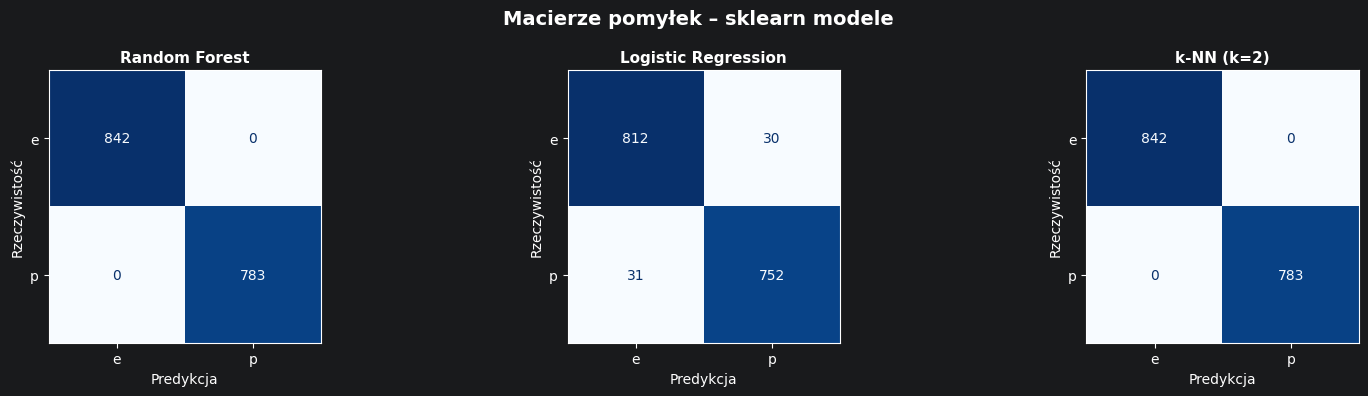


── Confusion matrix: własne drzewo decyzyjne ──


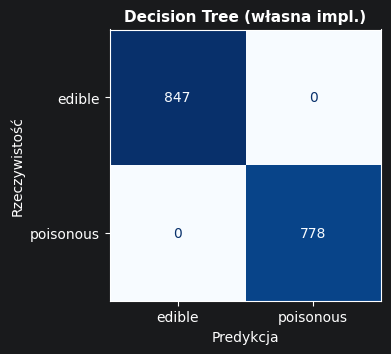

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Macierze pomyłek – sklearn modele", fontsize=14, fontweight="bold")

sklearn_models = [
    ("Random Forest",       rf,  X_test),
    ("Logistic Regression", lr,  X_test_s),
    ("k-NN (k=2)",          knn, X_test),
]

for ax, (name, model, Xt) in zip(axes, sklearn_models):
    y_pred = model.predict(Xt)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predykcja")
    ax.set_ylabel("Rzeczywistość")

plt.tight_layout()
plt.show()

# Confusion matrix dla własnego drzewa decyzyjnego
print("\n── Confusion matrix: własne drzewo decyzyjne ──")
y_pred_dt = [predict(tree, row) for _, row in test_df.iterrows()]
valid = [(true, pred) for true, pred in zip(test_df["class"], y_pred_dt) if pred is not None]
y_true_dt = [v[0] for v in valid]
y_pred_dt_clean = [v[1] for v in valid]

fig2, ax2 = plt.subplots(figsize=(4, 4))
cm_dt = confusion_matrix(y_true_dt, y_pred_dt_clean, labels=["e", "p"])
disp2 = ConfusionMatrixDisplay(cm_dt, display_labels=["edible", "poisonous"])
disp2.plot(ax=ax2, colorbar=False, cmap="Blues")
ax2.set_title("Decision Tree (własna impl.)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Predykcja")
ax2.set_ylabel("Rzeczywistość")
plt.tight_layout()
plt.show()

### Miary jakości: Accuracy, Precision, Recall, F1

- **Accuracy** – odsetek wszystkich poprawnych predykcji  
- **Precision** – ze wszystkich przewidzianych jako trujące, ile faktycznie było trujących  
- **Recall** – ze wszystkich trujących, ile zostało poprawnie wykrytych (ważniejsza miara dla bezpieczeństwa)  
- **F1-score** – średnia harmoniczna precision i recall

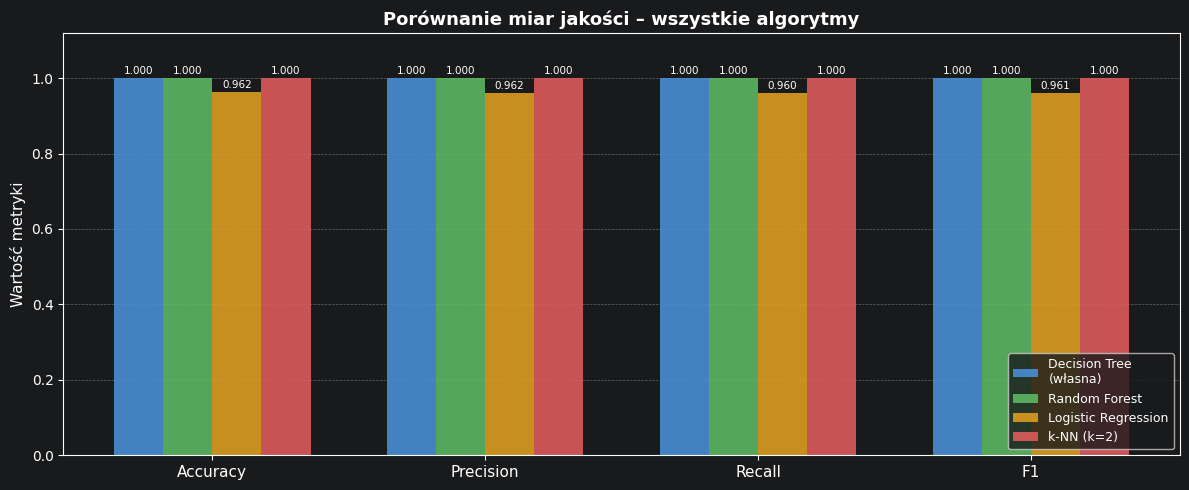

In [7]:
def get_metrics(y_true, y_pred, pos_label=1):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0),
        "F1":        f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0),
    }

# Encode 'e'/'p' to 0/1 for the custom DT
label_map = {"e": 0, "p": 1}
y_true_dt_enc = [label_map[v] for v in y_true_dt]
y_pred_dt_enc = [label_map[v] for v in y_pred_dt_clean]

metrics = {
    "Decision Tree\n(własna)": get_metrics(y_true_dt_enc, y_pred_dt_enc),
    "Random Forest":            get_metrics(y_test, rf.predict(X_test)),
    "Logistic Regression":      get_metrics(y_test, lr.predict(X_test_s)),
    "k-NN (k=2)":               get_metrics(y_test, knn.predict(X_test)),
}

metric_names = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(metric_names))
width = 0.18
colors = ["#4A90D9", "#5DBB63", "#E0A020", "#E05C5C"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + i * width, [vals[m] for m in metric_names],
                  width, label=model_name, color=colors[i], alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_ylim(0, 1.12)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel("Wartość metryki", fontsize=11)
ax.set_title("Porównanie miar jakości – wszystkie algorytmy", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Krzywe ROC i AUC

Krzywa ROC (Receiver Operating Characteristic) ilustruje kompromis między
czułością (Recall/TPR) a wskaźnikiem fałszywych alarmów (FPR) przy różnych
progach klasyfikacji.  
**AUC** (Area Under the Curve) – im bliżej 1.0, tym lepszy model.
Linia przerywana reprezentuje klasyfikator losowy (AUC = 0.5).

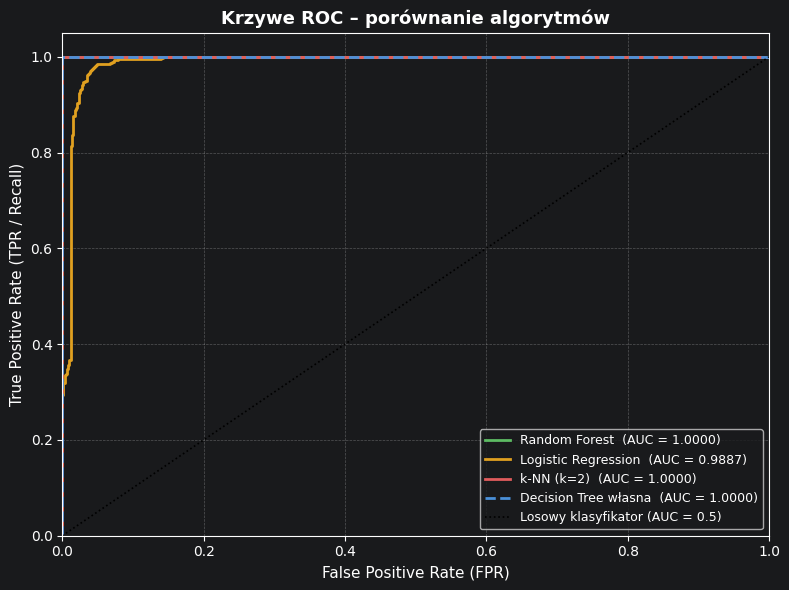

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

# sklearn models with predict_proba
roc_models = [
    ("Random Forest",       rf,  X_test,  "#5DBB63"),
    ("Logistic Regression", lr,  X_test_s,"#E0A020"),
    ("k-NN (k=2)",          knn, X_test,  "#E05C5C"),
]

for name, model, Xt, color in roc_models:
    proba = model.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {roc_auc:.4f})")

# Custom DT – binary scores (no probability → use 0/1 hard predictions)
fpr_dt, tpr_dt, _ = roc_curve(y_true_dt_enc, y_pred_dt_enc)
roc_auc_dt = auc(fpr_dt, tpr_dt)
ax.plot(fpr_dt, tpr_dt, color="#4A90D9", lw=2,
        linestyle="--", label=f"Decision Tree własna  (AUC = {roc_auc_dt:.4f})")

# Random baseline
ax.plot([0, 1], [0, 1], "k:", lw=1.2, label="Losowy klasyfikator (AUC = 0.5)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate (FPR)", fontsize=11)
ax.set_ylabel("True Positive Rate (TPR / Recall)", fontsize=11)
ax.set_title("Krzywe ROC – porównanie algorytmów", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Krzywa uczenia (Learning Curve)

Krzywa uczenia pokazuje jak zmienia się dokładność modelu w zależności od
liczby próbek treningowych.

- **Zbieżność krzywych** train/test oznacza dobrze dopasowany model  
- **Duży rozstęp** między nimi sugeruje overfitting (za dobrze dopasowany do danych treningowych)  
- Własne drzewo decyzyjne jest pominięte – nie ma API `fit(X, y)` kompatybilnego z `learning_curve`  
  (wymaga kategorycznych danych, nie zakodowanych liczbowo).

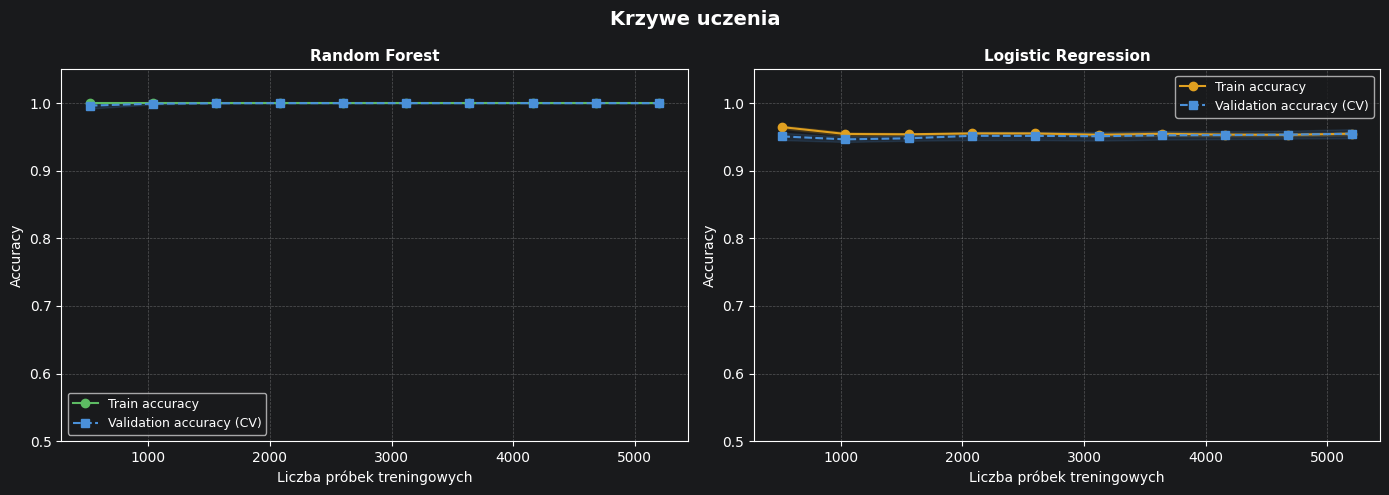

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Krzywe uczenia", fontsize=14, fontweight="bold")

lc_models = [
    ("Random Forest",       rf,  X_train,   y_train, axes[0], "#5DBB63"),
    ("Logistic Regression", lr,  X_train_s, y_train, axes[1], "#E0A020"),
]

train_sizes_pct = np.linspace(0.1, 1.0, 10)

for name, model, Xtr, ytr, ax, color in lc_models:
    train_sizes, train_scores, val_scores = learning_curve(
        model, Xtr, ytr,
        train_sizes=train_sizes_pct,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", color=color,       label="Train accuracy")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color=color)
    ax.plot(train_sizes, val_mean,   "s--", color="#4A90D9",  label="Validation accuracy (CV)")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color="#4A90D9")

    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Liczba próbek treningowych", fontsize=10)
    ax.set_ylabel("Accuracy", fontsize=10)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Porównanie końcowe – wszystkie algorytmy

Zestawienie accuracy wszystkich czterech metod na tym samym zbiorze testowym (20% danych).

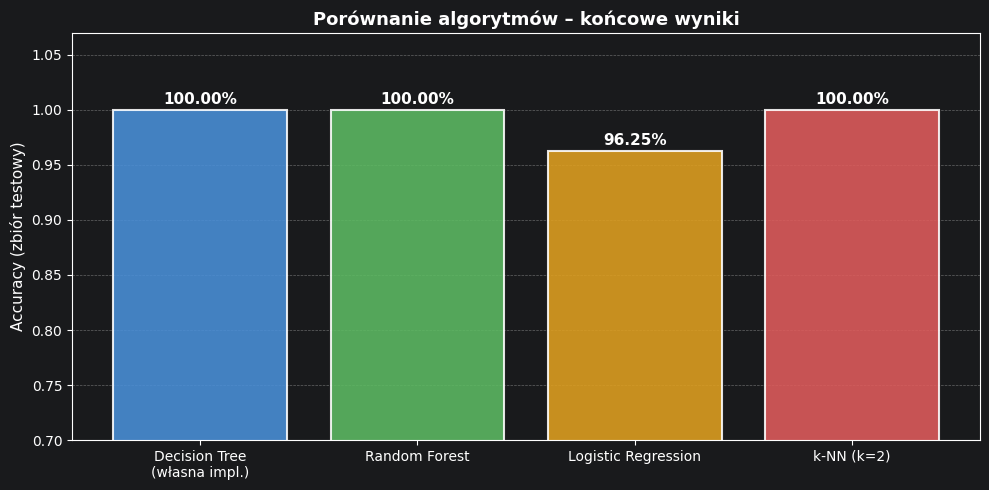


── Tabela końcowa ──────────────────────────────────────────────
  Algorytm                              Accuracy
──────────────────────────────────────────────────
  Decision Tree (własna impl.)           100.00%
  Random Forest                          100.00%
  k-NN (k=2)                             100.00%
  Logistic Regression                     96.25%
──────────────────────────────────────────────────


In [10]:
final_scores = {
    "Decision Tree\n(własna impl.)": dt_acc,
    "Random Forest":            accuracy_score(y_test, rf.predict(X_test)),
    "Logistic Regression":      accuracy_score(y_test, lr.predict(X_test_s)),
    "k-NN (k=2)":               accuracy_score(y_test, knn.predict(X_test)),
}

names  = list(final_scores.keys())
scores = list(final_scores.values())
colors_bar = ["#4A90D9", "#5DBB63", "#E0A020", "#E05C5C"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, scores, color=colors_bar, alpha=0.88, edgecolor="white", linewidth=1.5)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{score*100:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0.7, 1.07)
ax.set_ylabel("Accuracy (zbiór testowy)", fontsize=11)
ax.set_title("Porównanie algorytmów – końcowe wyniki", fontsize=13, fontweight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.tick_params(axis="x", labelsize=10)
plt.tight_layout()
plt.show()

print("\n── Tabela końcowa ──────────────────────────────────────────────")
print(f"  {'Algorytm':<35} {'Accuracy':>10}")
print("─" * 50)
for name, acc in sorted(final_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name.replace(chr(10),' '):<35} {acc*100:>9.2f}%")
print("─" * 50)